In [ ]:
from google.colab import files
files.upload()

Saving gnr638-assignment2.zip to gnr638-assignment2.zip


{'gnr638-assignment2.zip': b'PK\x03\x04\n\x00\x00\x00\x00\x00ydf\\\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x13\x00\t\x00gnr638-assignment2/UT\x05\x00\x01\xa7:\xabiPK\x03\x04\n\x00\x00\x00\x00\x00ydf\\\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x1b\x00\t\x00gnr638-assignment2/configs/UT\x05\x00\x01\xa7:\xabiPK\x03\x04\n\x00\x00\x00\x08\x00ydf\\\xf07\xd0X\x91\x01\x00\x00\xe3\x03\x00\x00-\x00\t\x00gnr638-assignment2/configs/model_configs.yamlUT\x05\x00\x01\xa7:\xabiuS\xdbn\x830\x0c}\xefW\xa0>O\x15\xb0n\x0f\xfd\x95i\x8aLpi\xd4\\\x90\x1dTu_?\'\x90\xaat\xec\x05%\xc7\xe7\xd8>vp\xa1G\xcb\xa7]U\x11\xb2\xc7\xf8Q\xa7sUE\xe3\x9c\xf2\xe0\xf0\xf4\x08d|$\x8c\x04\xc6c\x7f\xaa"M(`\x8f\x9eQ\x18M\xdb\xfc\xd1>\xc5\xfe\x93\xe3\xf9l\xb4A\x1f\x85\xa6\xba\xbf\xe5_\xe2\xdbiv\xf9j\xfc\x90\xe4\x8c\t?\xb6r\xec \xea\x8bb\xf3#\x89>\x8f\x02\xf8\xc9\xa9[\xa0+\x12\x0be\x01\xb4\x05f\x14\xe0=\xa57nX\x14m\x9b\x18a\x94n\xe4N\xa7\nzp\x82X9\xd6\x87\xbaN\x9enh\x86KT=j\xb8\xcf\xa8\xc0;\xd6\xe8\x81L\xc8\x93\xb5\xd

In [ ]:
!unzip gnr638-assignment2.zip
%cd gnr638-assignment2

Archive:  gnr638-assignment2.zip
70724621c0b8490e25c4f86afc24bcf6af9ed0fb
   creating: gnr638-assignment2/
   creating: gnr638-assignment2/configs/
  inflating: gnr638-assignment2/configs/model_configs.yaml  
   creating: gnr638-assignment2/data/
  inflating: gnr638-assignment2/data/dataset_instructions.md  
   creating: gnr638-assignment2/models/
  inflating: gnr638-assignment2/models/load_models.py  
  inflating: gnr638-assignment2/requirements.txt  
  inflating: gnr638-assignment2/scenario_1.ipynb  
  inflating: gnr638-assignment2/scenerio_5.ipynb  
   creating: gnr638-assignment2/utils/
  inflating: gnr638-assignment2/utils/corruption.py  
  inflating: gnr638-assignment2/utils/dataset_loader.py  
  inflating: gnr638-assignment2/utils/metrics.py  
/content/gnr638-assignment2


In [ ]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=4add6d0778d7f26c3dd854f0315ff475aaccf5ae36afd808eeb16dcd1da03fe4
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=ee72a2727b4297dcaeffc32c543fd0f6f59c9c52215e2fa75c6ced65620cebc5
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath


In [ ]:
!pip install gdown

In [ ]:
!gdown 1yBuXnJdjlTmVYw3fFovROyxaMP8XU815 -O Assignment2_data_gnr638.zip

Downloading...
From (original): https://drive.google.com/uc?id=1yBuXnJdjlTmVYw3fFovROyxaMP8XU815
From (redirected): https://drive.google.com/uc?id=1yBuXnJdjlTmVYw3fFovROyxaMP8XU815&confirm=t&uuid=3e2c2be8-c3ab-43d5-8744-233149b72c4b
To: /content/gnr638-assignment2/Assignment2_data_gnr638.zip
100% 1.83G/1.83G [00:15<00:00, 117MB/s]


In [ ]:
# !unzip "/content/gnr638-assignment2/Assignment2_data_gnr638.zip" -d /content/

In [ ]:
DATA_DIR = "/content/train_data"

In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import gc

from models.load_models import load_model
from utils.dataset_loader import get_dataloaders
from utils.corruption import get_corruption_transform
from utils.metrics import corruption_error, relative_robustness

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader, val_loader, classes = get_dataloaders(
    DATA_DIR,
    batch_size=16,   # important for GPU stability
    num_workers=2,
    img_size=224
)

num_classes = len(classes)

[Dataset] Train: 5594 | Val: 1399 | Fraction used: 1.0


In [ ]:
models = {
    "resnet50": "/content/resnet50_last_block.pth",
    "densenet121": "/content/densenet121_last_block.pth",
    "efficientnet_b0": "/content/efficientnet_b0_full_finetune.pth"
}

In [ ]:
def evaluate(model, loader, transform=None):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in tqdm(loader):

            if transform:
                images = transform(images)

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [ ]:
corruptions = {
    "clean": (None, None),
    "gaussian_0.05": ("gaussian", 0.05),
    "gaussian_0.1": ("gaussian", 0.1),
    "gaussian_0.2": ("gaussian", 0.2),
    "motion_blur": ("motion_blur", None),
    "brightness": ("brightness", 0.2)
}

In [ ]:
results = []

for model_name, path in models.items():

    print("\nEvaluating:", model_name)

    model = load_model(model_name, num_classes)
    model.load_state_dict(torch.load(path, map_location=device))
    model = model.to(device)

    # Clean accuracy
    clean_acc = evaluate(model, val_loader)

    for cname, (ctype, severity) in corruptions.items():

        if cname == "clean":
            acc = clean_acc

        else:
            transform = get_corruption_transform(ctype, severity)
            acc = evaluate(model, val_loader, transform)

        results.append({
            "model": model_name,
            "corruption": cname,
            "accuracy": acc,
            "CE": corruption_error(acc),
            "RR": relative_robustness(acc, clean_acc)
        })

    # free GPU memory before loading next model
    del model
    torch.cuda.empty_cache()
    gc.collect()


Evaluating: resnet50


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

100%|██████████| 88/88 [00:12<00:00,  7.29it/s]



Evaluating: densenet121


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

100%|██████████| 88/88 [00:12<00:00,  6.99it/s]



Evaluating: efficientnet_b0


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

100%|██████████| 88/88 [00:12<00:00,  7.31it/s]


In [ ]:
df = pd.DataFrame(results)
df

,model,corruption,accuracy,CE,RR
0,resnet50,clean,0.942102,0.057898,1.000000
1,resnet50,gaussian_0.05,0.212294,0.787706,0.225341
2,resnet50,gaussian_0.1,0.210150,0.789850,0.223065
3,resnet50,gaussian_0.2,0.187991,0.812009,0.199545
4,resnet50,motion_blur,0.551823,0.448177,0.585736
5,resnet50,brightness,0.279485,0.720515,0.296662
6,densenet121,clean,0.936383,0.063617,1.000000
7,densenet121,gaussian_0.05,0.213724,0.786276,0.228244
8,densenet121,gaussian_0.1,0.166548,0.833452,0.177863
9,densenet121,gaussian_0.2,0.090064,0.909936,0.096183


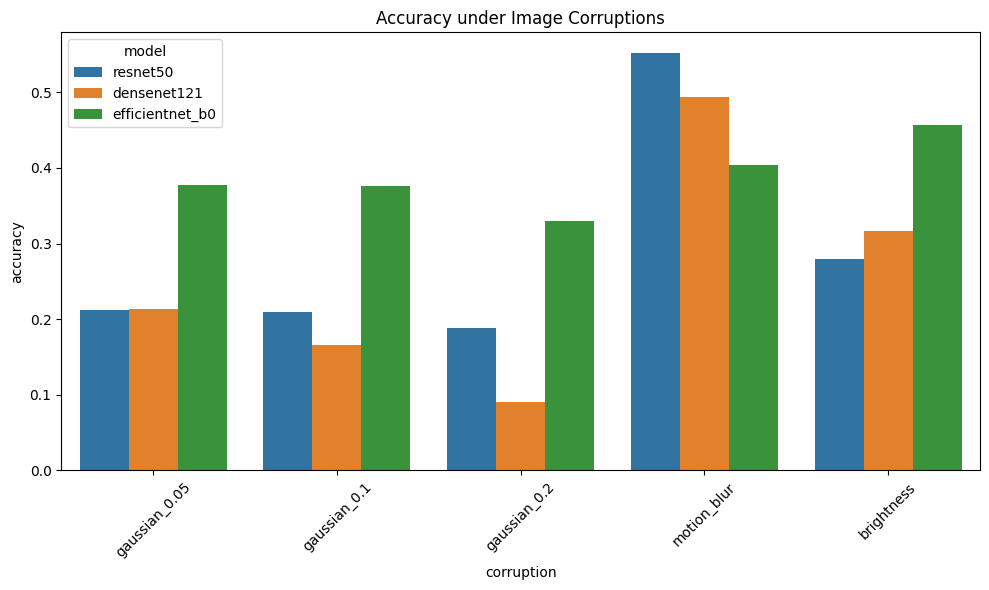

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df[df.corruption!="clean"],
    x="corruption",
    y="accuracy",
    hue="model"
)

plt.title("Accuracy under Image Corruptions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("scenario4_accuracy.png", dpi=300)

plt.show()

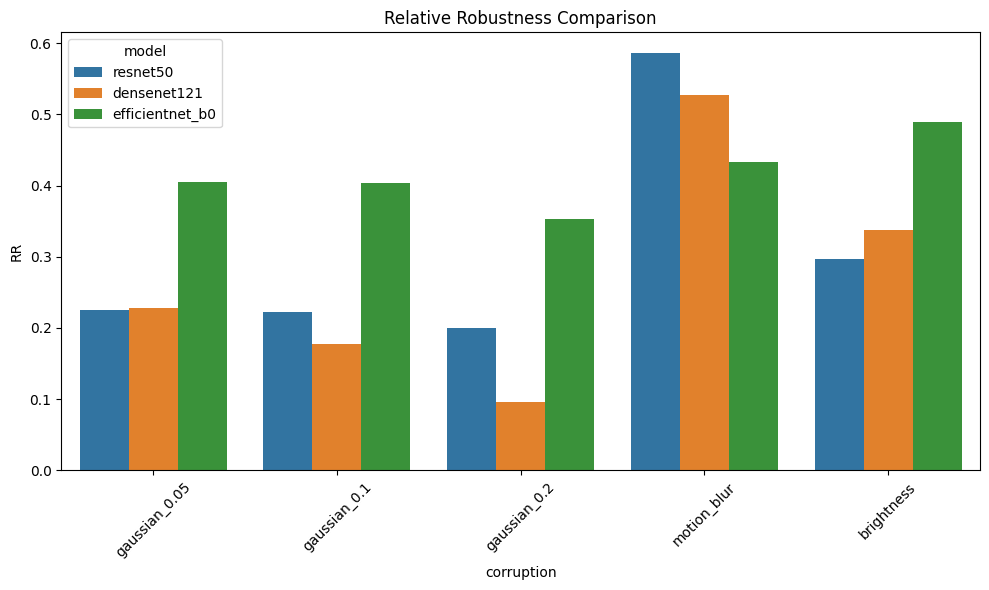

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df[df.corruption!="clean"],
    x="corruption",
    y="RR",
    hue="model"
)

plt.title("Relative Robustness Comparison")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("scenario4_relative_robustness.png", dpi=300)

plt.show()

Robustness to Image Corruptions

To evaluate model robustness, we tested the best fine-tuned models under several image corruptions, including Gaussian noise, motion blur, and brightness shifts. Clean validation accuracy for all models was approximately 0.94, providing a strong baseline for comparison.

Gaussian noise caused the most severe degradation in performance. For example, ResNet50 accuracy dropped from 0.94 to 0.19 under σ=0.2 noise, while DenseNet121 dropped further to 0.09. EfficientNet-B0 showed relatively better robustness, maintaining 0.33 accuracy under the same corruption level. This indicates that CNN models are highly sensitive to pixel-level noise perturbations.

Motion blur produced a smaller accuracy drop compared to noise. ResNet50 retained the highest performance under blur with 0.55 accuracy, followed by DenseNet121 (0.49) and EfficientNet-B0 (0.40). This suggests that spatial smoothing affects high-frequency details but preserves structural information useful for classification.

Brightness shifts caused moderate degradation across all models. EfficientNet-B0 demonstrated the highest robustness, achieving 0.46 accuracy, compared to 0.32 for DenseNet121 and 0.28 for ResNet50. This indicates that EfficientNet’s architecture may better handle illumination variations.

Relative robustness results further confirm these observations. EfficientNet-B0 consistently achieved higher robustness under Gaussian noise and brightness changes, while ResNet50 showed superior robustness under motion blur.

Overall, the results indicate that modern CNN architectures remain vulnerable to pixel-level noise but retain moderate robustness to blur and illumination changes.